In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded = files.upload()


Saving day_cleaned.csv to day_cleaned.csv
Saving hour_cleaned.csv to hour_cleaned.csv


In [3]:
day_df = pd.read_csv('day_cleaned.csv')
hour_df = pd.read_csv('hour_cleaned.csv')


In [4]:
def perform_eda(df, name):
    print(f"=== EDA for {name} Dataset ===\n")
    print("🔹 First 5 Rows:")
    display(df.head())

    print("\n🔹 Info:")
    df.info()
    print("\n")

    print(f"🔹 Shape: {df.shape}\n")

    # Nulls
    print("🔹 Null Values:")
    print(df.isnull().sum(), "\n")

    # Drop nulls
    df = df.dropna()
    print(f"✅ After dropping nulls: {df.shape}\n")

    # Duplicates
    print(f"🔹 Duplicate rows: {df.duplicated().sum()}")
    df = df.drop_duplicates()
    print(f"✅ After dropping duplicates: {df.shape}\n")

    # Outliers (IQR)
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    print("🔹 Outlier Detection (IQR Method):")
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{col}: {len(outliers)} outliers")

    # Remove outliers
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f"\n✅ After removing outliers: {df.shape}\n")

    # Summary
    print("🔹 Summary Statistics:")
    display(df.describe())

    # Correlation Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title(f'Correlation Heatmap - {name}')
    plt.show()

    return df


=== EDA for Day Dataset ===

🔹 First 5 Rows:


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB


🔹 Shape: (731, 11)

🔹 Null Values:
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64 

✅ After dropping nulls: (731, 11)

🔹 Duplicate rows: 0
✅ After dropping du

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,696.000000,696.000000,696.0,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000
mean,2.515805,6.551724,0.0,3.031609,0.705460,1.399425,0.498341,0.477238,0.632071,0.186074,4556.916667
std,1.101879,3.422763,0.0,2.006215,0.456164,0.545696,0.183095,0.162601,0.139935,0.071587,1924.688201
min,1.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.059130,0.079070,0.254167,0.022392,22.000000
25%,2.000000,4.000000,0.0,1.000000,0.000000,1.000000,0.341667,0.338378,0.524583,0.133721,3247.500000
50%,3.000000,7.000000,0.0,3.000000,1.000000,1.000000,0.507084,0.493050,0.630833,0.178481,4577.500000
75%,3.000000,9.000000,0.0,5.000000,1.000000,2.000000,0.656041,0.610645,0.733125,0.230258,6001.750000
max,4.000000,12.000000,0.0,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.378108,8714.000000


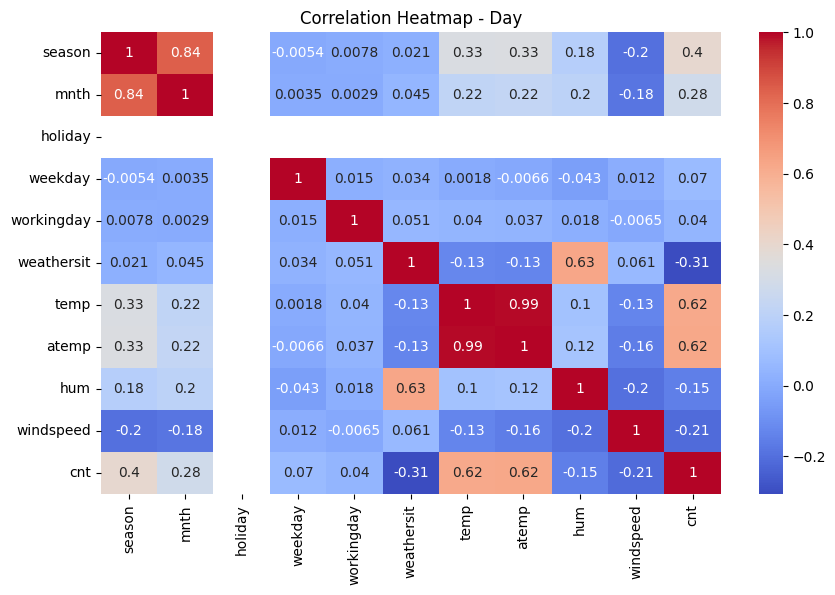

=== EDA for Hour Dataset ===

🔹 First 5 Rows:


,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   mnth        17379 non-null  int64  
 2   hr          17379 non-null  int64  
 3   holiday     17379 non-null  int64  
 4   weekday     17379 non-null  int64  
 5   workingday  17379 non-null  int64  
 6   weathersit  17379 non-null  int64  
 7   temp        17379 non-null  float64
 8   atemp       17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  cnt         17379 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 1.6 MB


🔹 Shape: (17379, 12)

🔹 Null Values:
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64 

✅ After drop

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,16040.000000,16040.000000,16040.000000,16040.0,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000
mean,2.507419,6.539027,11.415399,0.0,3.028928,0.699252,1.428990,0.495012,0.474507,0.634484,0.182238,174.072007
std,1.104579,3.434218,6.980771,0.0,2.017607,0.458598,0.639491,0.192107,0.170984,0.190462,0.111906,155.992032
min,1.000000,1.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,1.000000
25%,2.000000,4.000000,5.000000,0.0,1.000000,0.000000,1.000000,0.340000,0.333300,0.490000,0.104500,38.000000
50%,3.000000,7.000000,11.000000,0.0,3.000000,1.000000,1.000000,0.500000,0.484800,0.640000,0.164200,137.000000
75%,3.000000,10.000000,18.000000,0.0,5.000000,1.000000,2.000000,0.640000,0.621200,0.790000,0.253700,268.000000
max,4.000000,12.000000,23.000000,0.0,6.000000,1.000000,3.000000,1.000000,1.000000,1.000000,0.462700,645.000000


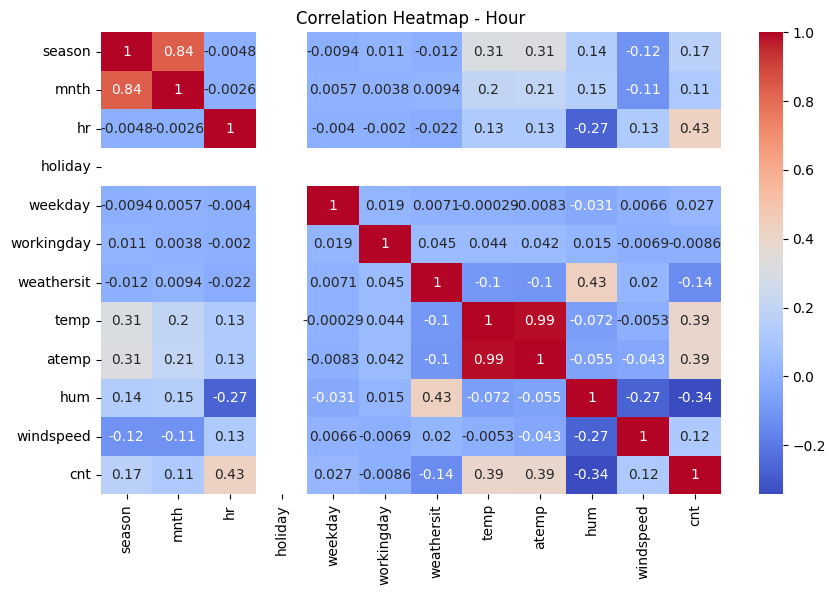

In [5]:
day_df_cleaned = perform_eda(day_df, "Day")
hour_df_cleaned = perform_eda(hour_df, "Hour")
